<a href="https://colab.research.google.com/github/Chunsen41/Chunsen41/blob/main/FootballAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
file_path = 'footballData.csv'
df = pd.read_csv(file_path)

# Show the first few rows
print(df.head())


   sofifa_id                                         player_url  \
0     158023  https://sofifa.com/player/158023/lionel-messi/...   
1      20801  https://sofifa.com/player/20801/c-ronaldo-dos-...   
2     200389  https://sofifa.com/player/200389/jan-oblak/210002   
3     188545  https://sofifa.com/player/188545/robert-lewand...   
4     190871  https://sofifa.com/player/190871/neymar-da-sil...   

          short_name                            long_name  age         dob  \
0           L. Messi       Lionel Andrés Messi Cuccittini   33  24/06/1987   
1  Cristiano Ronaldo  Cristiano Ronaldo dos Santos Aveiro   35  05/02/1985   
2           J. Oblak                            Jan Oblak   27  07/01/1993   
3     R. Lewandowski                   Robert Lewandowski   31  21/08/1988   
4          Neymar Jr        Neymar da Silva Santos Júnior   28  05/02/1992   

   height_cm  weight_kg nationality            club_name  ...   lwb   ldm  \
0        170         72   Argentina         FC Barc

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display only columns with missing values
missing_values = missing_values[missing_values > 0]

print("Missing values per column:")
print(missing_values)


Missing values per column:
club_name                 225
league_name               225
league_rank               225
release_clause_eur        995
player_tags             17536
team_position             225
team_jersey_number        225
loaned_from             18186
joined                    983
contract_valid_until      225
nation_position         17817
nation_jersey_number    17817
pace                     2083
shooting                 2083
passing                  2083
dribbling                2083
defending                2083
physic                   2083
gk_diving               16861
gk_handling             16861
gk_kicking              16861
gk_reflexes             16861
gk_speed                16861
gk_positioning          16861
player_traits           10629
defending_marking       18944
dtype: int64


In [ ]:
df.drop(columns=[
    'player_tags', 'loaned_from', 'nation_position', 'nation_jersey_number',
    'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning',
    'player_traits', 'defending_marking'
], inplace=True)


In [ ]:
df.dropna(subset=['club_name', 'league_name', 'league_rank'], inplace=True)


In [ ]:
stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

for col in stats:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-833696295.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df['release_clause_eur'].fillna(df['release_clause_eur'].median(), inplace=True)
df['joined'].fillna('Unknown', inplace=True)
df['contract_valid_until'].fillna('Unknown', inplace=True)
df['team_position'].fillna('Unknown', inplace=True)
df['team_jersey_number'].fillna(-1, inplace=True)


/tmp/ipython-input-3210669685.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['release_clause_eur'].fillna(df['release_clause_eur'].median(), inplace=True)
/tmp/ipython-input-3210669685.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [ ]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

sofifa_id      0
player_url     0
short_name     0
long_name      0
age            0
dob            0
height_cm      0
weight_kg      0
nationality    0
club_name      0
dtype: int64


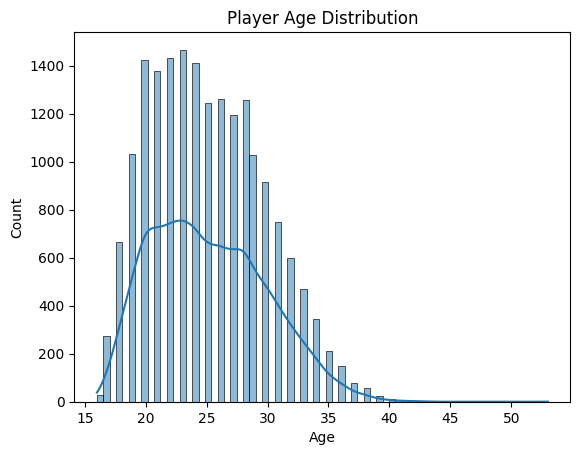

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
sns.histplot(df['age'], kde=True)
plt.title('Player Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

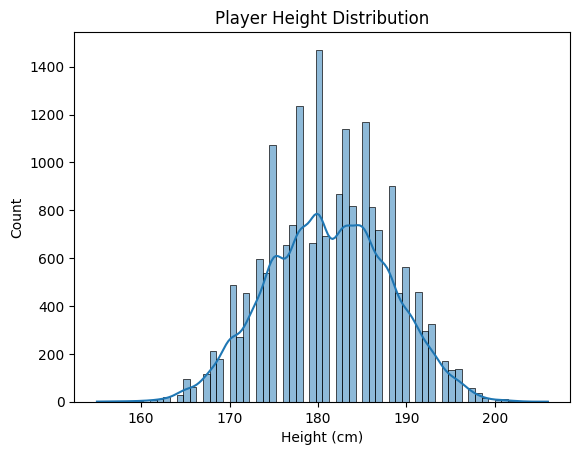

In [ ]:
# Height distribution
sns.histplot(df['height_cm'], kde=True)
plt.title('Player Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Count')
plt.show()

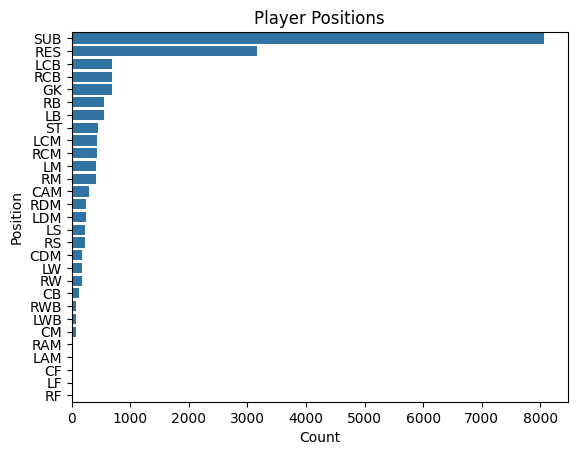

In [ ]:
# Position breakdown
sns.countplot(y='team_position', data=df, order=df['team_position'].value_counts().index)
plt.title('Player Positions')
plt.xlabel('Count')
plt.ylabel('Position')
plt.show()

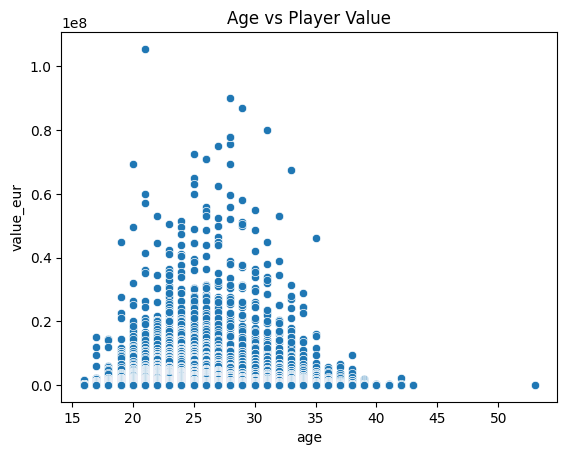

In [ ]:
# Age vs Value
sns.scatterplot(x='age', y='value_eur', data=df)
plt.title('Age vs Player Value')
plt.show()

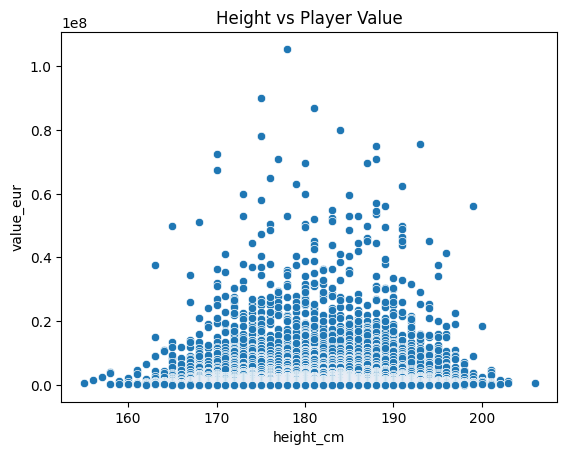

In [ ]:
# Height vs Value
sns.scatterplot(x='height_cm', y='value_eur', data=df)
plt.title('Height vs Player Value')
plt.show()

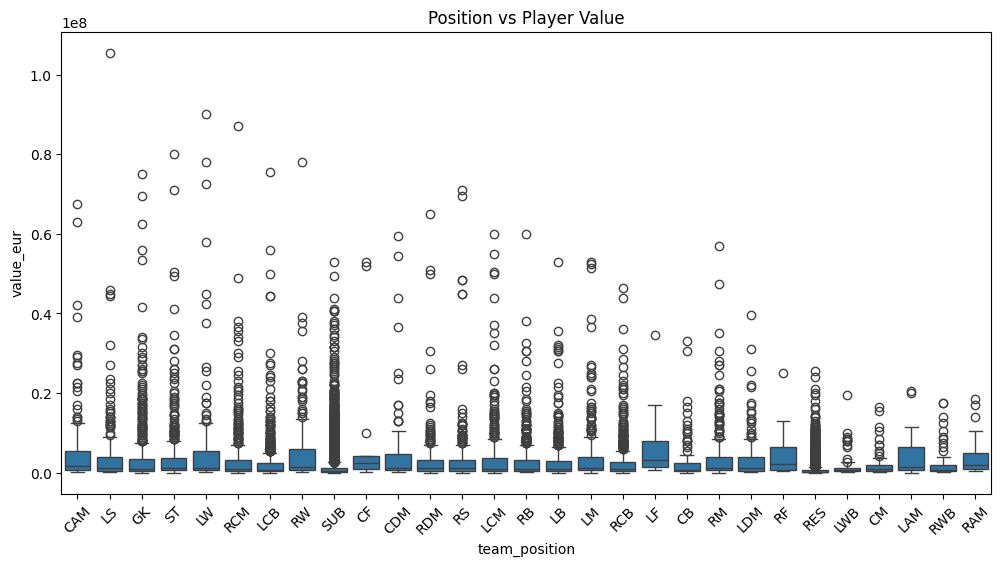

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='team_position', y='value_eur', data=df)
plt.title('Position vs Player Value')
plt.xticks(rotation=45)
plt.show()

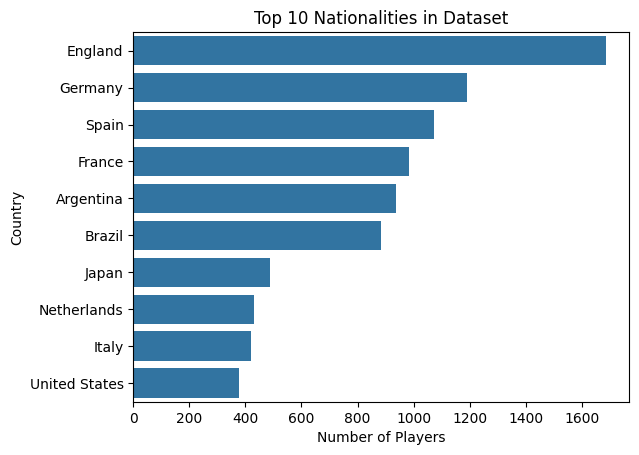

In [ ]:
# Nationality frequency
top_countries = df['nationality'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Nationalities in Dataset')
plt.xlabel('Number of Players')
plt.ylabel('Country')
plt.show()

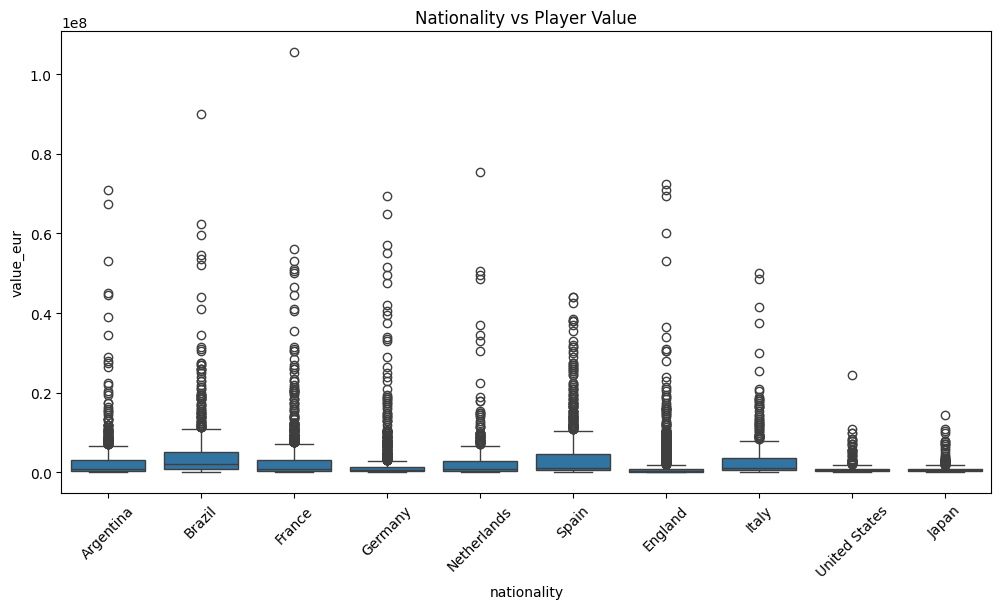

In [ ]:
# Boxplot: Nationality vs Value (top 10)
top_nations = df['nationality'].value_counts().head(10).index
df_top_nations = df[df['nationality'].isin(top_nations)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='nationality', y='value_eur', data=df_top_nations)
plt.title('Nationality vs Player Value')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Encode team_position and nationality_name
df_model = pd.get_dummies(df, columns=['team_position', 'nationality'], drop_first=True)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()
df_model[['age', 'height_cm']] = scaler.fit_transform(df_model[['age', 'height_cm']])


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Load ---
df = pd.read_csv("footballData.csv")

# --- Clean columns: trim + lowercase for consistency ---
df.columns = df.columns.str.strip().str.lower()

# --- Pick target automatically (prefer value_eur for market value tasks) ---
candidate_targets = [
    "value_eur",          # FIFA market value (EUR)
    "price",              # your earlier schema
    "max_price",          # your earlier schema
    "wage_eur",           # fallback if you want to predict wages instead
    "market_value",       # generic
    "price_eur"
]
target = next((c for c in candidate_targets if c in df.columns), None)
if target is None:
    raise KeyError(
        "No expected target found. Tried: "
        + ", ".join(candidate_targets)
        + "\nAvailable columns: "
        + str(df.columns.tolist())
    )

# --- Basic pruning: columns we don't want as features (IDs, names, urls, raw text/date strings) ---
drop_like = {
    "unnamed: 0", "sofifa_id", "player_url", "short_name", "long_name",
    "name", "full_name", "club", "club_name", "league", "league_name",
    "nationality", "place_of_birth", "player_positions", "player_tags",
    "player_traits", "team_position", "loaned_from", "body_type", "real_face",
    "dob", "joined", "contract_valid_until", "nation_position"
}
# Keep only columns that exist
to_drop = [c for c in drop_like if c in df.columns]

# --- Remove rows with missing target; simple NA handling for features later ---
df = df.dropna(subset=[target])

# --- Build X / y ---
X = df.drop(columns=list(set([target] + to_drop)))
y = df[target]

# --- Optional: simple NA handling for features ---
# Fill numeric NAs with column means
num_cols = X.select_dtypes(include="number").columns
X[num_cols] = X[num_cols].fillna(X[num_cols].mean())
# Drop any remaining non-numeric columns (keep it simple for now)
X = X.select_dtypes(include="number")

# --- Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Sanity prints ---
print(f"Target selected: {target}")
print(f"X shape: {X.shape} | Train: {X_train.shape} | Test: {X_test.shape}")
print("Feature columns:", X_train.columns.tolist()[:25], "..." if X_train.shape[1] > 25 else "")


Target selected: value_eur
X shape: (18944, 59) | Train: (15155, 59) | Test: (3789, 59)
Feature columns: ['age', 'height_cm', 'weight_kg', 'league_rank', 'overall', 'potential', 'wage_eur', 'international_reputation', 'weak_foot', 'skill_moves', 'release_clause_eur', 'team_jersey_number', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning'] ...


In [ ]:
drop_cols = [
    'sofifa_id', 'player_url', 'short_name', 'long_name', 'dob',
    'club_name', 'league_name', 'joined', 'contract_valid_until'
]


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Step 1: Drop known non-numeric/textual columns
drop_cols = [
    'sofifa_id', 'player_url', 'short_name', 'long_name', 'dob',
    'club_name', 'league_name', 'joined', 'contract_valid_until'
]

# Step 2: Create cleaned feature matrix (drop target + string columns)
X = df_model.drop(columns=[col for col in drop_cols if col in df_model.columns] + ['value_eur'])

# Step 3: Keep only numeric columns
X = X.select_dtypes(include=['number'])

# Step 4: Define target
y = df_model['value_eur']

# Step 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 7: Predict
y_pred = model.predict(X_test)

# Step 8: Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:,.2f}')
print(f'R² Score: {r2:.2f}')


RMSE: 538,094.16
R² Score: 0.99


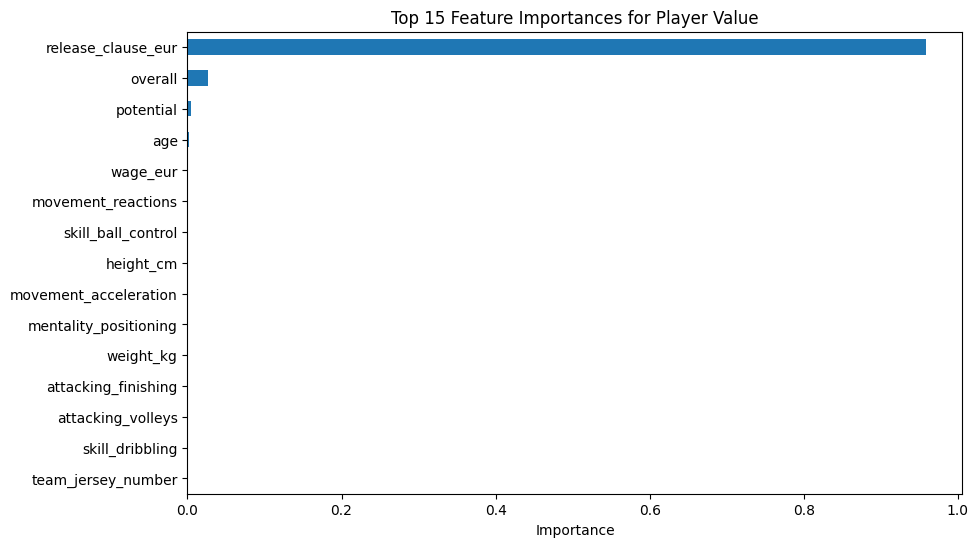

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_importances.plot(kind='barh')
plt.title('Top 15 Feature Importances for Player Value')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# STEP 1: Define DMatrix (optional, or just use sklearn API)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# STEP 2: Train
xgb_model.fit(X_train, y_train)

# STEP 3: Predict
y_pred_xgb = xgb_model.predict(X_test)

# STEP 4: Evaluate
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:,.2f}")
print(f"XGBoost R² Score: {r2_xgb:.2f}")


XGBoost RMSE: 501,742.58
XGBoost R² Score: 0.99


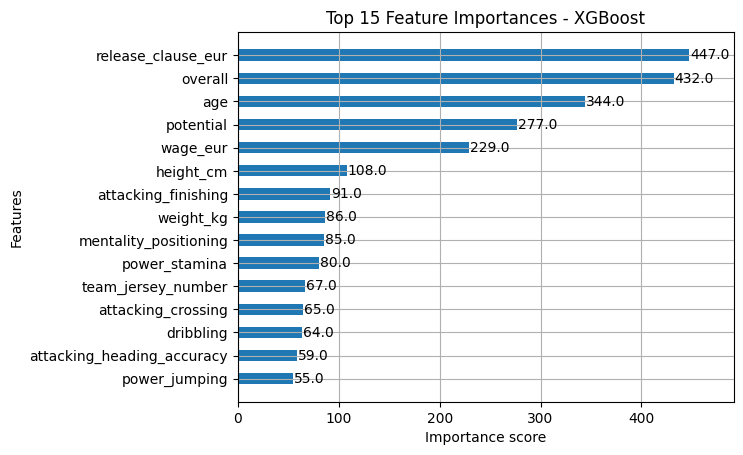

In [ ]:
import matplotlib.pyplot as plt

xgb.plot_importance(xgb_model, max_num_features=15, height=0.5)
plt.title('Top 15 Feature Importances - XGBoost')
plt.show()


In [ ]:
!pip install streamlit
!pip install pyngrok


In [ ]:
import joblib
joblib.dump(xgb_model, 'player_value_model.pkl')

['player_value_model.pkl']

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load('player_value_model.pkl')

positions = ['ST', 'CB', 'CAM', 'GK', 'CM', 'RW', 'LW', 'LB', 'RB']
nationalities = ['Brazil', 'Germany', 'Argentina', 'France', 'England', 'Spain', 'Portugal', 'Italy']

st.title("Football Player Value Predictor")

age = st.slider("Player Age", 16, 45, 25)
height = st.slider("Height (cm)", 150, 210, 180)
position = st.selectbox("Team Position", positions)
nationality = st.selectbox("Nationality", nationalities)

def create_input(age, height, position, nationality):
    data = {
        'age': [age],
        'height_cm': [height]
    }
    for pos in positions:
        data[f'team_position_{pos}'] = [1 if pos == position else 0]
    for nation in nationalities:
        data[f'nationality_{nation}'] = [1 if nation == nationality else 0]
    return pd.DataFrame(data)

if st.button("Predict Player Value (€)"):
    input_df = create_input(age, height, position, nationality)
    prediction = model.predict(input_df)[0]
    st.success(f"Estimated Market Value: €{prediction:,.2f}")


Writing app.py


In [ ]:
!pip install streamlit pyngrok --quiet


In [ ]:
!rm -rf ~/.ngrok2


In [ ]:
!pip install streamlit pyngrok --quiet


In [ ]:
!mkdir -p ~/.ngrok2
with open("/root/.ngrok2/ngrok.yml", "w") as f:
    f.write("authtoken: 2ybFqzUNEn6PLwfUCc5RDrxXFwL_2pJVxtzsT8mTYhiN4FRAP")


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('player_value_model.pkl')

positions = ['ST', 'CB', 'CAM', 'GK', 'CM', 'RW', 'LW', 'LB', 'RB']
nationalities = ['Brazil', 'Germany', 'Argentina', 'France', 'England', 'Spain', 'Portugal', 'Italy']

st.title("Football Player Value Predictor")

age = st.slider("Player Age", 16, 45, 25)
height = st.slider("Height (cm)", 150, 210, 180)
position = st.selectbox("Team Position", positions)
nationality = st.selectbox("Nationality", nationalities)

def create_input(age, height, position, nationality):
    data = {
        'age': [age],
        'height_cm': [height]
    }
    for pos in positions:
        data[f'team_position_{pos}'] = [1 if pos == position else 0]
    for nation in nationalities:
        data[f'nationality_{nation}'] = [1 if nation == nationality else 0]
    return pd.DataFrame(data)

if st.button("Predict Player Value (€)"):
    input_df = create_input(age, height, position, nationality)
    prediction = model.predict(input_df)[0]
    st.success(f"Estimated Market Value: €{prediction:,.2f}")


Overwriting app.py


In [ ]:
import joblib
joblib.dump(xgb_model, 'player_value_model.pkl')


['player_value_model.pkl']

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load model
model = joblib.load('player_value_model.pkl')

# Define positions and nationalities available in training
positions = ['ST', 'CB', 'CAM', 'GK', 'CM', 'RW', 'LW', 'LB', 'RB']
nationalities = ['Brazil', 'Germany', 'Argentina', 'France', 'England', 'Spain', 'Portugal', 'Italy']

st.set_page_config(page_title="Player Valuator", layout="centered")
st.title("Build a Football Player")
st.markdown("Select player traits and estimate their **market value** 💰")

# Input form
age = st.slider("Age", 16, 45, 25)
height = st.slider("Height (cm)", 150, 210, 180)
position = st.selectbox("Position", positions)
nationality = st.selectbox("Nationality", nationalities)

# Optional attributes
pace = st.slider("Pace", 20, 99, 70)
shooting = st.slider("Shooting", 20, 99, 65)
passing = st.slider("Passing", 20, 99, 60)
dribbling = st.slider("Dribbling", 20, 99, 68)
defending = st.slider("Defending", 20, 99, 50)
physic = st.slider("Physical", 20, 99, 70)

def create_input():
    data = {
        'age': [age],
        'height_cm': [height],
        'pace': [pace],
        'shooting': [shooting],
        'passing': [passing],
        'dribbling': [dribbling],
        'defending': [defending],
        'physic': [physic]
    }
    for pos in positions:
        data[f'team_position_{pos}'] = [1 if pos == position else 0]
    for nation in nationalities:
        data[f'nationality_{nation}'] = [1 if nation == nationality else 0]
    return pd.DataFrame(data)

# Predict
if st.button("Estimate Player Value"):
    input_df = create_input()
    value = model.predict(input_df)[0]
    st.success(f"Estimated Market Value: €{value:,.2f}")

    # Radar Chart
    st.markdown("Player Skill Radar")
    skills = [pace, shooting, passing, dribbling, defending, physic]
    labels = ['Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physical']

    angles = np.linspace(0, 2 * np.pi, len(skills), endpoint=False).tolist()
    skills += skills[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, skills, color='blue', linewidth=2)
    ax.fill(angles, skills, color='skyblue', alpha=0.4)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    st.pyplot(fig)


Overwriting app.py


In [ ]:
!pip install gradio --quiet


In [ ]:
import joblib
joblib.dump(xgb_model, 'player_value_model.pkl')

['player_value_model.pkl']

In [ ]:
def predict_value(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality):
    # Load full feature set from model
    expected_features = model.get_booster().feature_names

    # Initialize empty row with all zeros
    input_data = {feat: 0 for feat in expected_features}

    # Fill known values
    input_data['age'] = age
    input_data['height_cm'] = height_cm
    input_data['pace'] = pace
    input_data['shooting'] = shooting
    input_data['passing'] = passing
    input_data['dribbling'] = dribbling
    input_data['defending'] = defending
    input_data['physic'] = physic

    # One-hot encode position
    input_data[f'team_position_{position}'] = 1

    # One-hot encode nationality
    input_data[f'nationality_{nationality}'] = 1

    # Convert to DataFrame
    df_input = pd.DataFrame([input_data])

    # Predict
    prediction = model.predict(df_input)[0]
    return f" Estimated Market Value: €{prediction:,.2f}"


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib

# Load model
model = joblib.load('player_value_model.pkl')

positions = ['ST', 'CB', 'CAM', 'GK', 'CM', 'RW', 'LW', 'LB', 'RB']
nationalities = ['Brazil', 'Germany', 'Argentina', 'France', 'England', 'Spain', 'Portugal', 'Italy']

def predict_value(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality):
    # Build input dataframe
    data = {
        'age': [age],
        'height_cm': [height_cm],
        'pace': [pace],
        'shooting': [shooting],
        'passing': [passing],
        'dribbling': [dribbling],
        'defending': [defending],
        'physic': [physic]
    }

    for pos in positions:
        data[f'team_position_{pos}'] = [1 if pos == position else 0]
    for nat in nationalities:
        data[f'nationality_{nat}'] = [1 if nat == nationality else 0]

    df_input = pd.DataFrame(data)
    prediction = model.predict(df_input)[0]
    return f"€{prediction:,.2f}"

# Gradio UI
iface = gr.Interface(
    fn=predict_value,
    inputs=[
        gr.Slider(16, 45, label="Age"),
        gr.Slider(150, 210, label="Height (cm)"),
        gr.Slider(20, 99, step=1, label="Pace"),
        gr.Slider(20, 99, step=1, label="Shooting"),
        gr.Slider(20, 99, step=1, label="Passing"),
        gr.Slider(20, 99, step=1, label="Dribbling"),
        gr.Slider(20, 99, step=1, label="Defending"),
        gr.Slider(20, 99, step=1, label="Physical"),
        gr.Dropdown(positions, label="Position"),
        gr.Dropdown(nationalities, label="Nationality")
    ],
    outputs="text",
    title="Player Scouting System | Value Estimator",
    description="Choose player attributes and estimate their market value using an XGBoost model."
)

iface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d29b9d75bfc593c05b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d29b9d75bfc593c05b.gradio.live


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
import json
import os

# -------------------------
# Load model safely
# -------------------------
MODEL_PATH = "player_value_model.pkl"
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at '{MODEL_PATH}'. Make sure the .pkl is in the working directory.")

model = joblib.load(MODEL_PATH)

# Try to get the expected feature names from the model
def get_expected_features(m):
    # scikit-learn estimators trained on pandas usually have this:
    feats = getattr(m, "feature_names_in_", None)
    if feats is not None:
        return list(feats)
    # Some XGBoost models may expose names via booster
    booster = getattr(m, "get_booster", None)
    if booster is not None:
        try:
            names = m.get_booster().feature_names
            if names is not None:
                return list(names)
        except Exception:
            pass
    # Fallback: unknown (we'll just pass along what we have)
    return None

EXPECTED_FEATURES = get_expected_features(model)

# -------------------------
# Controlled vocabularies used in UI
# (must align with training one-hot prefixes)
# -------------------------
positions = ['ST', 'CB', 'CAM', 'GK', 'CM', 'RW', 'LW', 'LB', 'RB']
nationalities = ['Brazil', 'Germany', 'Argentina', 'France', 'England', 'Spain', 'Portugal', 'Italy']

# Prefixes must match how you created dummies during training.
# If your training used, e.g., pd.get_dummies(df['team_position'], prefix='team_position'),
# then the columns look like team_position_ST, team_position_CB, ...
POS_PREFIX = "team_position_"
NAT_PREFIX = "nationality_"

# -------------------------
# Build one input row and align it to the model
# -------------------------
def build_aligned_input(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality):
    # Core numeric features
    base = {
        "age": [int(age)],
        "height_cm": [float(height_cm)],
        "pace": [int(pace)],
        "shooting": [int(shooting)],
        "passing": [int(passing)],
        "dribbling": [int(dribbling)],
        "defending": [int(defending)],
        "physic": [int(physic)],  # NOTE: many FIFA datasets use 'physic' (not 'physical')
    }

    # One-hot for position
    for pos in positions:
        base[f"{POS_PREFIX}{pos}"] = [1 if pos == position else 0]

    # One-hot for nationality
    for nat in nationalities:
        base[f"{NAT_PREFIX}{nat}"] = [1 if nat == nationality else 0]

    df_input = pd.DataFrame(base)

    # If we know expected features, align exactly to them
    missing = []
    extra = []
    ordered_cols = None

    if EXPECTED_FEATURES is not None:
        # Add any missing expected columns as zeros
        for col in EXPECTED_FEATURES:
            if col not in df_input.columns:
                df_input[col] = 0
                missing.append(col)

        # Identify any extra columns we produced that the model doesn't expect
        extra = [c for c in df_input.columns if c not in EXPECTED_FEATURES]

        # Drop extras
        if extra:
            df_input = df_input.drop(columns=extra)

        # Reorder to match expected order exactly
        ordered_cols = EXPECTED_FEATURES
        df_input = df_input[ordered_cols]

    # Final numeric cast (safety)
    for c in df_input.columns:
        # try casting to float; if it fails, keep original
        try:
            df_input[c] = pd.to_numeric(df_input[c])
        except Exception:
            pass

    return df_input, missing, extra, ordered_cols

# -------------------------
# Prediction function for Gradio
# -------------------------
def predict_value(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality, show_debug):
    try:
        df_input, missing, extra, ordered_cols = build_aligned_input(
            age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality
        )

        # Inference
        pred = model.predict(df_input)[0]
        out = f"€{pred:,.2f}"

        # Optional debug info
        debug_info = {
            "expected_features_known": EXPECTED_FEATURES is not None,
            "input_columns_count": int(df_input.shape[1]),
            "missing_added": missing,
            "extra_dropped": extra,
        }
        if ordered_cols is not None:
            debug_info["first_15_expected_columns"] = ordered_cols[:15]

        debug_text = json.dumps(debug_info, indent=2)

        return (out, debug_text if show_debug else "")
    except Exception as e:
        # Return a friendly error string to the UI
        return ("Prediction failed.", f"Error: {repr(e)}")

# -------------------------
# Gradio UI
# -------------------------
with gr.Blocks(title="Player Scouting System | Value Estimator") as demo:
    gr.Markdown("# Player Scouting System | Value Estimator")
    gr.Markdown("Choose player attributes and estimate market value with your trained model. If something breaks, toggle **Show debug info**.")

    with gr.Row():
        age_in = gr.Slider(16, 45, value=24, step=1, label="Age")
        height_in = gr.Slider(150, 210, value=180, step=1, label="Height (cm)")

    with gr.Row():
        pace_in = gr.Slider(20, 99, value=80, step=1, label="Pace")
        shooting_in = gr.Slider(20, 99, value=75, step=1, label="Shooting")
        passing_in = gr.Slider(20, 99, value=78, step=1, label="Passing")

    with gr.Row():
        dribbling_in = gr.Slider(20, 99, value=80, step=1, label="Dribbling")
        defending_in = gr.Slider(20, 99, value=60, step=1, label="Defending")
        physic_in = gr.Slider(20, 99, value=75, step=1, label="Physical (physic)")

    with gr.Row():
        pos_in = gr.Dropdown(positions, value="ST", label="Position")
        nat_in = gr.Dropdown(nationalities, value="England", label="Nationality")

    show_debug = gr.Checkbox(False, label="Show debug info")

    predict_btn = gr.Button("Estimate Value")
    out_text = gr.Textbox(label="Estimated Market Value", interactive=False)
    debug_text = gr.Textbox(label="Debug", interactive=False, lines=12)

    predict_btn.click(
        fn=predict_value,
        inputs=[age_in, height_in, pace_in, shooting_in, passing_in, dribbling_in, defending_in, physic_in, pos_in, nat_in, show_debug],
        outputs=[out_text, debug_text]
    )

demo.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://793d8040228ad7cc1a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://793d8040228ad7cc1a.gradio.live


In [ ]:
# ---- imports ----
import os, json
import torch
import pandas as pd
import numpy as np
import joblib
import gradio as gr

# =========================
# 1) LOAD YOUR ESTIMATOR
# =========================
MODEL_PATH = "player_value_model.pkl"
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Missing {MODEL_PATH}. Put your trained .pkl here.")

estimator = joblib.load(MODEL_PATH)

# Try to learn expected feature order from the estimator (sklearn / xgb)
def get_expected_features(m):
    feats = getattr(m, "feature_names_in_", None)
    if feats is not None:
        return list(feats)
    booster = getattr(m, "get_booster", None)
    if booster is not None:
        try:
            names = m.get_booster().feature_names
            if names:
                return list(names)
        except Exception:
            pass
    return None

EXPECTED_FEATURES = get_expected_features(estimator)

# UI vocab
positions = ['ST', 'CB', 'CAM', 'GK', 'CM', 'RW', 'LW', 'LB', 'RB']
nationalities = ['Brazil', 'Germany', 'Argentina', 'France', 'England', 'Spain', 'Portugal', 'Italy']
POS_PREFIX = "team_position_"
NAT_PREFIX = "nationality_"

def build_aligned_input(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality):
    base = {
        "age": [int(age)],
        "height_cm": [float(height_cm)],
        "pace": [int(pace)],
        "shooting": [int(shooting)],
        "passing": [int(passing)],
        "dribbling": [int(dribbling)],
        "defending": [int(defending)],
        "physic": [int(physic)],
    }
    for pos in positions:
        base[f"{POS_PREFIX}{pos}"] = [1 if pos == position else 0]
    for nat in nationalities:
        base[f"{NAT_PREFIX}{nat}"] = [1 if nat == nationality else 0]
    df_in = pd.DataFrame(base)

    missing, extra = [], []
    if EXPECTED_FEATURES is not None:
        for col in EXPECTED_FEATURES:
            if col not in df_in.columns:
                df_in[col] = 0
                missing.append(col)
        extra = [c for c in df_in.columns if c not in EXPECTED_FEATURES]
        if extra:
            df_in = df_in.drop(columns=extra)
        df_in = df_in[EXPECTED_FEATURES]

    for c in df_in.columns:
        try:
            df_in[c] = pd.to_numeric(df_in[c])
        except Exception:
            pass
    return df_in, missing, extra

def predict_value(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality, show_debug):
    try:
        df_in, missing, extra = build_aligned_input(
            age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality
        )
        pred = estimator.predict(df_in)[0]
        out = f"€{pred:,.2f}"
        debug = {"expected_features_known": EXPECTED_FEATURES is not None,
                 "missing_added": missing, "extra_dropped": extra,
                 "input_shape": df_in.shape}
        return out, (json.dumps(debug, indent=2) if show_debug else "")
    except Exception as e:
        return "Prediction failed.", f"Error: {repr(e)}"

# =========================
# 2) SET UP TRANSFORMERS CHATBOT
# =========================
# Pick a compact instruct model; change if you prefer.
# Small + fast options:
#   - "Qwen/Qwen2.5-1.5B-Instruct"  (great quality, ~1.5B)
#   - "TinyLlama/TinyLlama-1.1B-Chat-v1.0" (tiny footprint)
CHAT_MODEL_ID = os.environ.get("CHAT_MODEL_ID", "Qwen/Qwen2.5-1.5B-Instruct")

from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer

def load_chat_model(model_id=CHAT_MODEL_ID):
    load_4bit = False
    try:
        import bitsandbytes as bnb  # noqa: F401
        load_4bit = True
    except Exception:
        load_4bit = False

    kwargs = dict(
        device_map="auto",
    )
    if torch.cuda.is_available():
        # FP16 or 4-bit if available
        if load_4bit:
            kwargs.update(dict(load_in_4bit=True))
        else:
            kwargs.update(dict(torch_dtype=torch.float16))
    else:
        kwargs.update(dict(torch_dtype=torch.float32))

    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    mdl = AutoModelForCausalLM.from_pretrained(model_id, **kwargs)
    return tok, mdl

tokenizer, chat_model = load_chat_model()

SYSTEM_PROMPT = "You are a friendly football analytics assistant. Be concise and helpful."

def format_messages(user_message, history):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT}]
    for u, a in history:
        if u:
            msgs.append({"role": "user", "content": u})
        if a:
            msgs.append({"role": "assistant", "content": a})
    msgs.append({"role": "user", "content": user_message})
    return msgs

def chat_reply(message, history, temperature=0.7, max_new_tokens=256, top_p=0.9):
    # Build a chat prompt using the model's chat template if available
    msgs = format_messages(message, history)
    if hasattr(tokenizer, "apply_chat_template"):
        prompt = tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True
        )
        input_ids = tokenizer(prompt, return_tensors="pt").to(chat_model.device)
    else:
        # Simple fallback prompt
        prompt = SYSTEM_PROMPT + "\n" + "\n".join(
            [f"User: {u}\nAssistant: {a}" for u, a in history if u or a]
        ) + f"\nUser: {message}\nAssistant:"
        input_ids = tokenizer(prompt, return_tensors="pt").to(chat_model.device)

    gen_ids = chat_model.generate(
        **input_ids,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )
    out_text = tokenizer.decode(gen_ids[0][input_ids["input_ids"].shape[1]:], skip_special_tokens=True)
    return out_text.strip()

# =========================
# 3) GRADIO UI (TABS)
# =========================
with gr.Blocks(title="Player Scouting System | Value + Chat") as demo:
    gr.Markdown("# Build a Player | Value + Chat")
    with gr.Tabs():
        # --- Tab 1: Estimator ---
        with gr.Tab("Value Estimator"):
            gr.Markdown("Estimate market value from attributes. Toggle **Show debug info** if needed.")
            with gr.Row():
                age_in = gr.Slider(16, 45, value=24, step=1, label="Age")
                height_in = gr.Slider(150, 210, value=180, step=1, label="Height (cm)")
            with gr.Row():
                pace_in = gr.Slider(20, 99, value=80, step=1, label="Pace")
                shooting_in = gr.Slider(20, 99, value=75, step=1, label="Shooting")
                passing_in = gr.Slider(20, 99, value=78, step=1, label="Passing")
            with gr.Row():
                dribbling_in = gr.Slider(20, 99, value=80, step=1, label="Dribbling")
                defending_in = gr.Slider(20, 99, value=60, step=1, label="Defending")
                physic_in = gr.Slider(20, 99, value=75, step=1, label="Physical (physic)")
            with gr.Row():
                pos_in = gr.Dropdown(positions, value="ST", label="Position")
                nat_in = gr.Dropdown(nationalities, value="England", label="Nationality")
            show_debug = gr.Checkbox(False, label="Show debug info")

            predict_btn = gr.Button("Estimate Value")
            out_text = gr.Textbox(label="Estimated Market Value", interactive=False)
            debug_text = gr.Textbox(label="Debug", interactive=False, lines=12)

            predict_btn.click(
                fn=predict_value,
                inputs=[age_in, height_in, pace_in, shooting_in, passing_in, dribbling_in, defending_in, physic_in, pos_in, nat_in, show_debug],
                outputs=[out_text, debug_text]
            )

        # --- Tab 2: Chatbot ---
        with gr.Tab("Chat (Transformers)"):
            gr.Markdown("Chat with a small Transformers model (runs locally).")
            chatbot = gr.Chatbot(height=420)
            with gr.Row():
                msg = gr.Textbox(placeholder="Ask about player value, features, or football analytics…", scale=4)
                send = gr.Button("Send", variant="primary", scale=1)
            with gr.Accordion("Generation settings", open=False):
                temp = gr.Slider(0.1, 1.2, value=0.7, step=0.05, label="Temperature")
                max_new = gr.Slider(32, 1024, value=256, step=16, label="Max new tokens")
                topp = gr.Slider(0.1, 1.0, value=0.9, step=0.05, label="Top-p")

            def user_send(user_message, chat_history):
                if not user_message or not user_message.strip():
                    return "", chat_history
                chat_history = chat_history + [(user_message, None)]
                return "", chat_history

            def bot_reply(chat_history, temperature, max_new_tokens, top_p):
                user_message = chat_history[-1][0]
                # Build history tuples with only finished pairs
                finished = [(u, a) for u, a in chat_history[:-1] if a is not None]
                answer = chat_reply(user_message, finished, temperature=temperature,
                                    max_new_tokens=int(max_new_tokens), top_p=top_p)
                chat_history[-1] = (user_message, answer)
                return chat_history

            send.click(user_send, inputs=[msg, chatbot], outputs=[msg, chatbot]) \
                .then(bot_reply, inputs=[chatbot, temp, max_new, topp], outputs=[chatbot])

demo.launch(debug=True)


In [ ]:
"""
Build a Player — Gradio Prototype (football-themed, version-agnostic)

- Works with Gradio 3.x and 4.x (no Dataframe height kw, tuple-style Chatbot)
- Uses your model if present (MODEL_PATH), else a clear (demo) fallback
- Keeps a Recent Outputs log and a CSV download
"""

from __future__ import annotations
import os, json, tempfile
from datetime import datetime
from typing import List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import joblib
import gradio as gr

# -------------------------
# Config / Globals
# -------------------------
MODEL_PATH = os.environ.get("MODEL_PATH", "player_value_model.pkl")
CHAT_MODEL_ID = os.environ.get("CHAT_MODEL_ID", "Qwen/Qwen2.5-1.5B-Instruct")

POSITIONS = ['ST', 'CB', 'CAM', 'GK', 'CM', 'RW', 'LW', 'LB', 'RB']
NATIONALITIES = ['Brazil', 'Germany', 'Argentina', 'France', 'England', 'Spain', 'Portugal', 'Italy']
POS_PREFIX = "team_position_"
NAT_PREFIX = "nationality_"

estimator = None
EXPECTED_FEATURES: Optional[List[str]] = None

PRED_LOG: List[dict] = []          # in-memory outputs log
MAX_LOG = 1000

# transformers optional
TRANSFORMERS_OK = True
try:
    import torch  # noqa
    from transformers import AutoTokenizer, AutoModelForCausalLM
except Exception:
    TRANSFORMERS_OK = False
tokenizer = None
chat_model = None

# -------------------------
# Utilities
# -------------------------
def get_expected_features(m) -> Optional[List[str]]:
    feats = getattr(m, "feature_names_in_", None)
    if feats is not None:
        return list(feats)
    booster = getattr(m, "get_booster", None)
    if booster is not None:
        try:
            names = m.get_booster().feature_names
            if names:
                return list(names)
        except Exception:
            pass
    return None

def try_load_estimator():
    global estimator, EXPECTED_FEATURES
    if estimator is None and os.path.exists(MODEL_PATH):
        estimator = joblib.load(MODEL_PATH)
        EXPECTED_FEATURES = get_expected_features(estimator)
    return estimator

def build_aligned_input(
    age:int, height_cm:float, pace:int, shooting:int, passing:int,
    dribbling:int, defending:int, physic:int, position:str, nationality:str
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    base = {
        "age":[int(age)], "height_cm":[float(height_cm)], "pace":[int(pace)],
        "shooting":[int(shooting)], "passing":[int(passing)], "dribbling":[int(dribbling)],
        "defending":[int(defending)], "physic":[int(physic)],
    }
    for pos in POSITIONS:
        base[f"{POS_PREFIX}{pos}"] = [1 if pos == position else 0]
    for nat in NATIONALITIES:
        base[f"{NAT_PREFIX}{nat}"] = [1 if nat == nationality else 0]
    df = pd.DataFrame(base)

    missing, extra = [], []
    if EXPECTED_FEATURES is not None:
        for col in EXPECTED_FEATURES:
            if col not in df.columns:
                df[col] = 0
                missing.append(col)
        extra = [c for c in df.columns if c not in EXPECTED_FEATURES]
        if extra:
            df = df.drop(columns=extra)
        df = df[EXPECTED_FEATURES]

    for c in df.columns:
        try: df[c] = pd.to_numeric(df[c])
        except Exception: pass
    return df, missing, extra

def predict_core(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality, show_debug):
    """Returns: (value_str, debug_text, log_df)"""
    # try real model first
    try_load_estimator()
    if estimator is not None:
        try:
            df_in, missing, extra = build_aligned_input(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality)
            pred = float(estimator.predict(df_in)[0])
            value_str = f"€{pred:,.2f}"
            demo = False
            debug = {
                "expected_features_known": EXPECTED_FEATURES is not None,
                "input_shape": list(df_in.shape),
                "missing_added": missing,
                "extra_dropped": extra,
                "first_15_cols": (EXPECTED_FEATURES[:15] if EXPECTED_FEATURES else []),
                "demo": demo
            } if show_debug else None
            # log
            row = {
                "ts": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
                "age": age, "height_cm": height_cm, "pace": pace, "shooting": shooting,
                "passing": passing, "dribbling": dribbling, "defending": defending, "physic": physic,
                "position": position, "nationality": nationality,
                "predicted_value_eur": round(pred, 2), "predicted_value_str": value_str, "demo": demo
            }
            PRED_LOG.append(row)
            if len(PRED_LOG) > MAX_LOG:
                del PRED_LOG[: len(PRED_LOG) - MAX_LOG]
            df_log = pd.DataFrame(PRED_LOG[::-1])  # newest first
            return value_str, (json.dumps(debug, indent=2) if debug else ""), df_log
        except Exception:
            pass  # fall through to demo

    # demo fallback (transparent)
    score = (1.2*pace + 1.3*shooting + 1.1*passing + 1.25*dribbling + 0.9*defending + 1.0*physic)
    age_adj = max(0.0, 45 - age) * 6.0
    height_adj = max(0.0, 200.0 - abs(height_cm - 180.0)) * 0.25
    total = score + age_adj + height_adj
    euro = float(np.clip(total * 100000, 100000, 200_000_000))
    value_str = f"€{euro:,.2f} (demo)"
    demo = True
    debug = {"demo": True, "formula": "linear heuristic with age/height adjustments"} if show_debug else None
    row = {
        "ts": datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
        "age": age, "height_cm": height_cm, "pace": pace, "shooting": shooting,
        "passing": passing, "dribbling": dribbling, "defending": defending, "physic": physic,
        "position": position, "nationality": nationality,
        "predicted_value_eur": round(euro, 2), "predicted_value_str": value_str, "demo": demo
    }
    PRED_LOG.append(row)
    if len(PRED_LOG) > MAX_LOG:
        del PRED_LOG[: len(PRED_LOG) - MAX_LOG]
    df_log = pd.DataFrame(PRED_LOG[::-1])
    return value_str, (json.dumps(debug, indent=2) if debug else ""), df_log

def download_csv():
    """Return a path to a temp CSV of the current log."""
    if not PRED_LOG:
        tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".csv")
        tmp.write(b"")
        tmp.flush(); tmp.close()
        return tmp.name
    df = pd.DataFrame(PRED_LOG)
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".csv")
    df.to_csv(tmp.name, index=False)
    return tmp.name

# Chat helpers (tuple-style history to support Gradio 3.x & 4.x)
def load_chat_model():
    global tokenizer, chat_model
    if not TRANSFORMERS_OK:
        raise RuntimeError("transformers not installed. pip install transformers accelerate")
    if tokenizer is None or chat_model is None:
        kwargs: dict[str, Any] = {}
        try:
            if torch.cuda.is_available():
                kwargs["torch_dtype"] = torch.float16
                kwargs["device_map"] = "auto"
            else:
                kwargs["torch_dtype"] = torch.float32
        except Exception:
            pass
        tokenizer = AutoTokenizer.from_pretrained(CHAT_MODEL_ID, use_fast=True)
        chat_model = AutoModelForCausalLM.from_pretrained(CHAT_MODEL_ID, **kwargs)
    return tokenizer, chat_model

def chat_reply(history_pairs: list[tuple[str, str]], user_message: str,
               temperature: float, max_new_tokens: int, top_p: float) -> str:
    """Return assistant reply. `history_pairs` is list of (user, assistant)."""
    if not TRANSFORMERS_OK:
        return "(local chat unavailable — install transformers & accelerate)"
    tok, mdl = load_chat_model()
    system_prompt = "You are a friendly football analytics assistant. Be concise and helpful."
    # build messages
    msgs = [{"role": "system", "content": system_prompt}]
    for u, a in history_pairs:
        if u: msgs.append({"role": "user", "content": u})
        if a: msgs.append({"role": "assistant", "content": a})
    msgs.append({"role": "user", "content": user_message})

    if hasattr(tok, "apply_chat_template"):
        prompt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)  # type: ignore
    else:
        conv = "\n".join([f"User: {u}\nAssistant: {a}" for u, a in history_pairs if (u or a)])
        prompt = f"{system_prompt}\n{conv}\nUser: {user_message}\nAssistant:"

    inputs = tok(prompt, return_tensors="pt")
    try:
        device = next(mdl.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}
    except Exception:
        pass

    out_ids = mdl.generate(
        **inputs,
        do_sample=True,
        temperature=float(temperature),
        top_p=float(top_p),
        max_new_tokens=int(max_new_tokens),
        eos_token_id=tok.eos_token_id,
        pad_token_id=tok.eos_token_id,
    )
    return tok.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

# -------------------------
# Beautiful football CSS
# -------------------------
CSS = """
:root {
  --grass1: #0c3b1a;
  --grass2: #0e5a27;
  --line: #eaf5ff;
  --card: rgba(255,255,255,0.08);
  --muted: #a7c5b3;
  --text: #f8fff9;
  --accent: #00e08a;
  --accent2: #2bd4ff;
  --shadow: 0 12px 40px rgba(0,0,0,.35);
  --radius: 18px;
}
body {
  background: repeating-linear-gradient(
    90deg, var(--grass1) 0, var(--grass1) 80px, var(--grass2) 80px, var(--grass2) 160px
  );
  font-family: Inter, system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif;
  color: var(--text);
}
#root { padding: 16px }
.header { display:flex; align-items:center; gap:12px; padding: 6px 0 16px; }
.badge {
  background: #ffffff10; color: var(--muted); border:1px solid #ffffff1a;
  padding:6px 10px; border-radius: 999px; font-size: 12px;
}
.card {
  background: var(--card); backdrop-filter: blur(8px); border:1px solid #ffffff1a;
  border-radius: var(--radius); box-shadow: var(--shadow); padding: 16px;
}
h1, h2, h3 { margin: 0 0 6px 0 }
.value-box {
  background:#0b1d14; border:1px dashed #ffffff3a; padding:12px; border-radius:12px;
  display:flex; align-items:center; justify-content:space-between;
}
.value-box strong { font-size: 20px }
"""

# -------------------------
# Gradio App
# -------------------------
def app():
    with gr.Blocks(css=CSS, title="Player Scouting System · Gradio") as demo:
        # Header
        gr.HTML(
            '<div class="header">'
            '  <div style="font-size:28px">⚽️</div>'
            '  <div>'
            '    <h1>Player Scouting System — Value Estimator & Chat</h1>'
            '    <div class="badge">Football-themed · Model-ready</div>'
            '  </div>'
            '</div>'
        )

        with gr.Row():
            # ----- Estimator Card -----
            with gr.Column(scale=3, elem_classes=["card"]):
                gr.Markdown("### Value Estimator")
                with gr.Row():
                    age = gr.Slider(16, 45, value=24, step=1, label="Age")
                    height_cm = gr.Slider(150, 210, value=180, step=1, label="Height (cm)")
                with gr.Row():
                    pace = gr.Slider(20, 99, value=80, step=1, label="Pace")
                    shooting = gr.Slider(20, 99, value=75, step=1, label="Shooting")
                    passing = gr.Slider(20, 99, value=78, step=1, label="Passing")
                with gr.Row():
                    dribbling = gr.Slider(20, 99, value=80, step=1, label="Dribbling")
                    defending = gr.Slider(20, 99, value=60, step=1, label="Defending")
                    physic = gr.Slider(20, 99, value=75, step=1, label="Physical (physic)")
                with gr.Row():
                    position = gr.Dropdown(POSITIONS, value="ST", label="Position")
                    nationality = gr.Dropdown(NATIONALITIES, value="England", label="Nationality")
                show_debug = gr.Checkbox(False, label="Show debug info")

                btn = gr.Button("Estimate Value", variant="primary")
                value_out = gr.Textbox(label="Estimated Market Value", interactive=False)
                debug_out = gr.Textbox(label="Debug", interactive=False, lines=10)

                with gr.Accordion("Recent Outputs", open=True):
                    outputs_df = gr.Dataframe(
                        headers=["ts","age","height_cm","pace","shooting","passing","dribbling","defending","physic","position","nationality","predicted_value_str","demo"],
                        row_count=(0, "dynamic"),
                        datatype=["str","number","number","number","number","number","number","number","number","str","str","str","bool"],
                        wrap=True,
                        interactive=False
                        # NOTE: no 'height=' kwarg -> compatible with Gradio 3.x/4.x
                    )
                    dl_file = gr.File(label="Download CSV")

            # ----- Chat Card -----
            with gr.Column(scale=2, elem_classes=["card"]):
                gr.Markdown("### Chat (Transformers)")
                chat = gr.Chatbot(height=420)  # tuple history style for 3.x/4.x
                chat_state = gr.State([])      # list[tuple[str,str]]

                with gr.Row():
                    chat_in = gr.Textbox(placeholder="Ask about player value, features, or football analytics…", scale=4)
                    chat_btn = gr.Button("Send", scale=1)
                with gr.Accordion("Generation settings", open=False):
                    temp = gr.Slider(0.1, 1.2, value=0.7, step=0.05, label="Temperature")
                    max_new = gr.Slider(32, 1024, value=256, step=16, label="Max new tokens")
                    topp = gr.Slider(0.1, 1.0, value=0.9, step=0.05, label="Top-p")

                def user_submit(msg, history):
                    if not msg or not msg.strip():
                        return gr.update(value=""), history
                    history = history + [(msg.strip(), None)]
                    return gr.update(value=""), history

                def bot_respond(history, temperature, max_new_tokens, top_p):
                    user_message = history[-1][0]
                    finished_pairs = [(u, a) for u, a in history[:-1] if u or a]
                    answer = chat_reply(finished_pairs, user_message, float(temperature), int(max_new_tokens), float(top_p))
                    history[-1] = (user_message, answer)
                    return history

                chat_btn.click(user_submit, inputs=[chat_in, chat_state], outputs=[chat_in, chat_state]) \
                        .then(bot_respond, inputs=[chat_state, temp, max_new, topp], outputs=[chat_state]) \
                        .then(lambda h: h, inputs=[chat_state], outputs=[chat])
                chat_in.submit(user_submit, inputs=[chat_in, chat_state], outputs=[chat_in, chat_state]) \
                      .then(bot_respond, inputs=[chat_state, temp, max_new, topp], outputs=[chat_state]) \
                      .then(lambda h: h, inputs=[chat_state], outputs=[chat])

        # Prediction event
        def predict_wrap(age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality, show_debug):
            val, dbg, df_log = predict_core(int(age), float(height_cm), int(pace), int(shooting), int(passing),
                                            int(dribbling), int(defending), int(physic), position, nationality,
                                            bool(show_debug))
            if df_log is None or df_log.empty:
                display_df = pd.DataFrame(columns=["ts","age","height_cm","pace","shooting","passing","dribbling","defending","physic","position","nationality","predicted_value_str","demo"])
            else:
                cols = ["ts","age","height_cm","pace","shooting","passing","dribbling","defending","physic","position","nationality","predicted_value_str","demo"]
                for c in cols:
                    if c not in df_log.columns:
                        df_log[c] = None
                display_df = df_log[cols]
            csv_path = download_csv()
            return val, dbg, display_df, csv_path

        btn.click(
            predict_wrap,
            inputs=[age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality, show_debug],
            outputs=[value_out, debug_out, outputs_df, dl_file]
        )

        # Manual refresh/download (optional)
        def refresh_download():
            df_log = pd.DataFrame(PRED_LOG[::-1]) if PRED_LOG else pd.DataFrame(columns=["ts","age","height_cm","pace","shooting","passing","dribbling","defending","physic","position","nationality","predicted_value_str","demo"])
            cols = ["ts","age","height_cm","pace","shooting","passing","dribbling","defending","physic","position","nationality","predicted_value_str","demo"]
            for c in cols:
                if c not in df_log.columns:
                    df_log[c] = None
            csv_path = download_csv()
            return df_log[cols], csv_path

        refresh_btn = gr.Button("Refresh & Download CSV", variant="secondary")
        refresh_btn.click(refresh_download, inputs=[], outputs=[outputs_df, dl_file])

        # Auto-run once on load so the page shows an output immediately
        demo.load(
            predict_wrap,
            inputs=[age, height_cm, pace, shooting, passing, dribbling, defending, physic, position, nationality, show_debug],
            outputs=[value_out, debug_out, outputs_df, dl_file]
        )

    return demo

if __name__ == "__main__":
    app = app()
    app.launch()


/tmp/ipython-input-2273884619.py:321: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chat = gr.Chatbot(height=420)  # tuple history style for 3.x/4.x


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a8f46d0ac20e0f660e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
